# Spectral Metric for Dataset Complexity Assessment

25 de agosto de 2026

En este script vamos a entender y programar la medida de complejidad del paper "Branchaud-Charron, F., Achkar, A., & Jodoin, P. M. (2019, June). Spectral metric for dataset complexity assessment. In 2019 IEEE/CVF Conference on Computer Vision and Pattern Recognition (CVPR) (pp. 3210-3219). IEEE.".

Es una medida de complejidad específicamente creada para datos de imágenes. El objetivo es programarla para que nos podamos comparar con ella.

Vamos copiando la información esencial para comprenderlo bien:

_Instead of processing raw input data like previous approaches, our method first projects the input images onto a lower-dimensional latent space. This allows to analyze data whose features are better adapted to what CNNs learn. Our method then estimates pairwise class overlap with a Monte-Carlo method which leads to an inter-class similarity matrix. Following the spectral clustering theory, we compute a K × K Laplacian matrix where K is the number of classes. Finally, the spectrum of this matrix is used to derived our cumulative spectral gradient (CSG) c-measure._
The main advantages of our proposed c-measure are as follows :
1. _It naturally scales with the number of classes and the number of images in the dataset;_
2. _Our metric is fast to compute and does not require the computation of prohibitively large matrices;_
3. _It has no prior assumption on the distribution of the data;_
4. _It gives a strong insight on which classes are easily separable and those that are entangled;_
5. _The metric is highly correlated with CNN generalization capabilities;_
6. _It can be easily used for dataset reduction._

Dicen:
_To our knowledge, **C. Li, H. Farkhoor, R. Liu, and J. Yosinski. Measuring the intrinsic dimension of objective landscapes. In Proc. ICLR, 2018.** are the only ones who proposed a c-measure applied specifically to modern image
datasets and deep neural networks. They called their measure the Intrinsic Dimension which is the minimum number
of neurons a model needs to reach its best performances. They show that adding more neurons past the Intrinsic Dimension does not improve test accuracy. Unfortunately, as opposed to what we seek to do, their measure requires multiple training of image classification CNNs through a grid-search approach which is slow and tedious._

REVISAR ESA COMPLEXITY MEASURE PARA NOMBRARLA EN EL PAPER.

# CSG: *Cumulative Spectral Gradient*

El objetivo de la métrica **CSG (Cumulative Spectral Gradient)** es asignar un único número a un problema de clasificación que refleje cómo de difícil es separar sus clases.

La idea es: Un problema de clasificación es más complejo cuando las distribuciones de sus clases se solapan más en el espacio de representación. CSG intenta estimar esta dificultad a partir de la propia geometría y distribución de los datos.

## 1. Dataset y espacio de representación

Consideremos un dataset etiquetado

$$
\mathcal D =
\{(x_1,t_1),\ldots,(x_N,t_N)\},
$$

donde:

- $x_n$ es una observación, por ejemplo una imagen;
- $t_n$ es su etiqueta de clase;
- existen $K$ clases distintas:
  $C_1,\ldots,C_K$.

El método no trabaja directamente sobre los datos originales $x$ si no que aplica una función de representación previa

$$
\phi(x)\in\mathbb R^d.
$$

Por tanto, el algoritmo trabaja realmente con

$$
\mathcal D_\phi =
\{(\phi(x_1),t_1),\ldots,(\phi(x_N),t_N)\}.
$$

La función $\phi$ debería producir un espacio donde observaciones similares estén próximas entre sí.


# 2. Medición del solapamiento entre dos clases

Supongamos dos clases $C_i$ y $C_j$.

En el espacio de embeddings, cada clase induce una distribución de probabilidad:

$$
p_i(z)
=
p(z\mid C_i),
$$

$$
p_j(z)
=
p(z\mid C_j),
$$

donde

$$
z=\phi(x).
$$

Si las dos distribuciones están muy separadas, las clases deberían ser fáciles de distinguir. Si se solapan mucho, la clasificación debería ser más difícil.

Una medida directa de solapamiento (medida teórica como la que presentamos nosotros en paper de Hostilidad) sería

$$
\int_{\mathbb R^d}
\min\left(
p_i(z),p_j(z)
\right)\,dz.
$$

Esta cantidad es grande cuando ambas distribuciones asignan probabilidad a las mismas regiones del espacio. Esta integral no se puede calcular si la distribución es desconocida o nos movemos en espacios de alta dimensión.

# 3. Probability Product Kernel

Como el solapamiento entre 2 clases está relacionado con la similitud entre las distribuciones de las clases, se puede usar una función de distancia de distribuciones de probabilidad como la divergencia de Kullback-Leibler o el test de Kolgomorov-Smirnov como una manera de estimar/aproximar dicha ecuación de solapamiento teórico. Un ejemplo de este tipo de funciones es el Probability Product Kernel de Jebara et al.:
$$
K_\rho(C_i,C_j)
=
\int_{\mathbb R^d}
p_i(z)^\rho
p_j(z)^\rho
\,dz.
$$
que es la generalización del kernel de Bhattacharyya kernel (y la distancia de Hellinger) cuando $\rho= 1/2$.
El cálculo de esta ecuación se simplifica cuando $\rho=1$ y, por ello, toman dicho valor. Así, la ecuación se convierte en el siguiente inner-product entre distribuciones:
$$
K(C_i,C_j)
=
\int_{\mathbb R^d}
p_i(z)p_j(z)\,dz.
$$
Esta cantidad también es grande cuando las dos distribuciones tienen densidad elevada en las mismas regiones.

La ventaja de utilizar $\rho=1$ es que la integral puede interpretarse como una esperanza matemática. Por definición,
$$
\mathbb E_{Z\sim p_i}[f(Z)]
=
\int f(z)p_i(z)\,dz.
$$
Si elegimos $f(z)=p_j(z),$ obtenemos
$$
\int p_i(z)p_j(z)\,dz
=
\mathbb E_{Z\sim p_i}
\left[
p_j(Z)
\right].
$$
Por simetría de la integral también se cumple
$$
\int p_i(z)p_j(z)\,dz
=
\mathbb E_{Z\sim p_j}
\left[
p_i(Z)
\right].
$$
La interpretación es: Tomamos puntos generados por la clase $C_i$ y preguntamos qué densidad les asigna la distribución de la clase $C_j$. Si los puntos de $C_i$ suelen encontrarse en regiones donde $C_j$ también tiene densidad alta, ambas clases están solapadas.

# 4. Aproximación Monte Carlo

La esperanza anterior tampoco puede calcularse exactamente porque las distribuciones de las clases son desconocidas. Sin embargo, una esperanza puede aproximarse mediante Monte Carlo.

Si tomamos
$$
z_1,\ldots,z_M
\overset{\text{i.i.d.}}{\sim}
p_i(z),
$$

entonces

$$
\mathbb E_{Z\sim p_i}
[p_j(Z)]
\approx
\frac{1}{M}
\sum_{m=1}^{M}
p_j(z_m).
$$

Por tanto, para estimar cuánto se solapa $C_i$ con $C_j$:

1. se toman $M$ observaciones de la clase $C_i$;
2. para cada observación se calcula cuánto vale la densidad de $C_j$ en ese punto;
3. se hace la media.

El resultado se utiliza como una entrada de una matriz de similitud entre clases:

$$
S\in\mathbb R^{K\times K}.
$$

Esquemáticamente,

$$
S_{ij}
\approx
\frac{1}{M}
\sum_{m=1}^{M}
\hat p(z_m\mid C_j),
\qquad
z_m\sim C_i.
$$

Por tanto, $S_{ij}$ responde aproximadamente a la pregunta: ¿Qué densidad de la clase $C_j$ encuentran, en promedio, los puntos que pertenecen a $C_i$?

# 5. Estimación de la densidad mediante vecinos cercanos

Todavía queda un problema: generalmente no conocemos la distribución $p(z\mid C_j).$ En el artículo la estiman mediante el k-nn.

Consideran una pequeña región de volumen $V$ alrededor de un punto $z$. Si se dispone de $M$ muestras de la clase $C_j$ y dentro de esa región hay $K_{C_j}$ muestras, la fracción de muestras de $C_j$ que cae en ella es aproximadamente

$$
\frac{K_{C_j}}{M}.
$$

Por otra parte, si la región es suficientemente pequeña, se puede aproximar la masa de probabilidad por

$$
P(Z\in V\mid C_j)
\approx
p(z\mid C_j)V.
$$

Igualando ambas expresiones:

$$
p(z\mid C_j)V
\approx
\frac{K_{C_j}}{M}.
$$

Por tanto,

$$
\boxed{
\hat p(z\mid C_j)
=
\frac{K_{C_j}}{MV}
}
$$

Esta es la estimación de densidad utilizada en el paper.

Intuitivamente,

$$
\text{densidad}
\approx
\frac{\text{número de puntos encontrados}}
{\text{número total de puntos}\times\text{volumen observado}}.
$$

Una región pequeña que contiene muchos puntos implica una densidad elevada.


# 6. Matriz de similitud entre clases $S$

Repitiendo el procedimiento para cada par de clases $(C_i,C_j),$ se construye
$$
S =
\begin{pmatrix}
S_{11} & \cdots & S_{1K}\\
\vdots & \ddots & \vdots\\
S_{K1} & \cdots & S_{KK}
\end{pmatrix}.
$$

Cada clase queda así caracterizada por un vector de relaciones con todas las demás clases.

Por ejemplo, una firma (entendiendo firma por ese vector que representa cómo se relaciona cada clase con el resto de clases) podría ser

$$
S_i =
(S_{i1},S_{i2},\ldots,S_{iK}).
$$

Este vector describe cómo se relaciona la clase $C_i$ con el conjunto de clases del problema.

Aunque el kernel teórico $\int p_i(z)p_j(z)\,dz$ es simétrico, la matriz $S$ obtenida numéricamente no tiene por qué serlo: $S_{ij}\neq S_{ji}.$
Esto se debe a que ambos términos son estimaciones Monte Carlo diferentes:
$$
S_{ij}
\approx
\frac{1}{M}
\sum_{z_m\sim C_i}
\hat p(z_m\mid C_j),
$$
mientras que
$$
S_{ji}
\approx
\frac{1}{M}
\sum_{\tilde z_m\sim C_j}
\hat p(\tilde z_m\mid C_i).
$$
Se utilizan puntos distintos y además las densidades se estiman numéricamente mediante vecinos cercanos.
Por esta razón, $S$ no puede utilizarse directamente como matriz de adyacencia de un grafo no dirigido (es la base del clustering espectral que aplican).

# 7. De $S$ a una matriz de adyacencia simétrica $W$

La siguiente idea consiste en considerar el vector asociado a cada clase como una *firma*. Dos clases serán consideradas similares si presentan perfiles similares respecto al resto de clases. Para comparar las *firmas* de $C_i$ y $C_j$ se utiliza una versión de la distancia de Bray-Curtis:
$$
d_{ij}
=
\frac{
\sum_{k=1}^{K}
|S_{ik}-S_{jk}|
}{
\sum_{k=1}^{K}
|S_{ik}+S_{jk}|
}.
$$
El numerador mide cuánto difieren las dos firmas:
$$
\sum_k |S_{ik}-S_{jk}|.
$$
El denominador normaliza esa diferencia por el tamaño total de ambas firmas:
$$
\sum_k |S_{ik}+S_{jk}|.
$$
Como $d_{ij}$ es una disimilitud, los autores la convierten en similitud mediante
$$
\boxed{
w_{ij}
=
1-d_{ij}
=
1-
\frac{
\sum_{k=1}^{K}
|S_{ik}-S_{jk}|
}{
\sum_{k=1}^{K}
|S_{ik}+S_{jk}|
}
}
$$

Los valores tienen la interpretación
$$
w_{ij}\approx1
\quad\Longrightarrow\quad
C_i\text{ y }C_j\text{ tienen perfiles muy similares},
$$

mientras que

$$
w_{ij}\approx0
\quad\Longrightarrow\quad
C_i\text{ y }C_j\text{ tienen perfiles muy diferentes}.
$$

Además, $w_{ij}=w_{ji},$ por lo que $W=W^\top.$ Ya se puede usar $W$ como la matriz de adyacencia de un grafo no dirigido de clases.

# 8. Grafo de clases

Se construye un grafo $G=(V,E)$ en el que:

- cada nodo representa una clase;
- existen $K$ nodos;
- el peso de la conexión entre $C_i$ y $C_j$ es $w_{ij}$.

Por tanto:

$$
\text{nodo }i
\longleftrightarrow
C_i.
$$

Si $w_{ij}\approx1,$ las clases están fuertemente relacionadas. Si $w_{ij}\approx0,$ las clases están prácticamente desconectadas. Un dataset fácil debería producir un grafo donde las clases sean relativamente independientes. Un dataset difícil debería producir un grafo más fuertemente conectado debido al mayor solapamiento entre clases.

# 9. Laplaciano del grafo

A partir de $W$ se define la matriz de grados
$$
D=
\operatorname{diag}(d_1,\ldots,d_K),
$$

donde
$$
d_i
=
\sum_{j=1}^{K}w_{ij}.
$$

El Laplaciano no normalizado es

$$
\boxed{
L=D-W
}
$$

El Laplaciano resume la estructura de conectividad del grafo. Una identidad importante para entender su significado es

$$
f^\top Lf
=
\frac12
\sum_{i,j}
w_{ij}(f_i-f_j)^2.
$$

Por tanto, si dos nodos están fuertemente conectados, es decir, $w_{ij}$ es grande, el Laplaciano penaliza que $f_i$ y $f_j$ sean muy distintos.

Esta propiedad es la base de la conexión entre el Laplaciano y el spectral clustering.

# 10. Espectro del Laplaciano

Como $L$ es simétrica y semidefinida positiva, sus autovalores son reales y no negativos.

Los ordenamos: $0=\lambda_0
\le
\lambda_1
\le
\cdots
\le
\lambda_{K-1}.$

Al conjunto $\{\lambda_0,\ldots,\lambda_{K-1}\}$ se le denomina espectro del Laplaciano.

En spectral clustering, los autovectores asociados a autovalores pequeños están relacionados con particiones del grafo de bajo coste. Una forma intuitiva de verlo es que, si $Lv=\lambda v$ y $v$ está normalizado, $v^\top Lv=\lambda.$

Por tanto, un autovalor pequeño implica $ \frac12 \sum_{i,j}w_{ij}(v_i-v_j)^2$ pequeño.

Esto significa que el autovector puede permanecer aproximadamente constante dentro de grupos de nodos muy conectados y cambiar principalmente entre grupos unidos débilmente.


# 11. Interpretación del espectro como complejidad

Esta es la idea central del CSG.

Si las clases están bien separadas, los pesos entre clases son pequeños: $w_{ij}\approx0.$ Entonces $W$ es relativamente dispersa y el espectro del Laplaciano contiene principalmente valores pequeños.

En cambio, si muchas clases están solapadas, aparecen conexiones fuertes entre ellas: $w_{ij}\text{ grande}.$ Esto conduce a un espectro con autovalores mayores.

Por tanto, los autores relacionan

$$
\boxed{
\text{espectro bajo}
\longleftrightarrow
\text{dataset sencillo}
}
$$

y

$$
\boxed{
\text{espectro alto}
\longleftrightarrow
\text{dataset complejo}.
}
$$

Sin embargo, no solo importa la magnitud de los autovalores. También importa cómo crece el espectro.


# 12. Eigengaps

Se define eigengap como el salto entre dos autovalores consecutivos:

$$
\Delta\lambda_i
=
\lambda_{i+1}-\lambda_i.
$$

Por ejemplo, si

$$
\lambda=
(0,\;0.05,\;0.10,\;1.2,\;1.4),
$$

entonces existe un salto importante entre

$$
0.10
\quad\text{y}\quad
1.2.
$$

El eigengap correspondiente es

$$
1.2-0.10=1.10.
$$

Los autores sostienen que, además del tamaño total del espectro, importa la posición en la que aparece un gradiente fuerte. Un salto grande situado pronto en el espectro tiene una interpretación distinta de un salto del mismo tamaño situado al final.

# 13. Eigengap normalizado

Para incorporar tanto el tamaño del eigengap como su posición, el paper introduce

$$
\boxed{
\Delta\lambda_{e_i}
=
\frac{
\lambda_{i+1}-\lambda_i
}{
K-i
}
}
$$

Esta normalización por $K-i$ forma parte específica de la definición del CSG.

El resultado es una secuencia de gradientes normalizados:

$$
\Delta\lambda_e
=
(
\Delta\lambda_{e_1},
\Delta\lambda_{e_2},
\ldots
).
$$

En otras palabras, primero se transforma $\lambda_1,\lambda_2,\ldots,\lambda_K$ en diferencias consecutivas $\lambda_{i+1}-\lambda_i,$ y posteriormente estas diferencias se ponderan según su posición en el espectro.


# 14. Máximo acumulado: `cummax`

El último ingrediente es la operación $\operatorname{cummax}.$

Para una secuencia $a=(a_1,a_2,\ldots,a_n),$ se define

$$
\operatorname{cummax}(a)_i
=
\max(a_1,\ldots,a_i).
$$

Por ejemplo, $a=(0.10,\;0.20,\;0.80,\;0.30,\;0.40)$ produce

$$
\operatorname{cummax}(a)
=
(0.10,\;0.20,\;0.80,\;0.80,\;0.80).
$$

Una vez aparece un gradiente grande, ese valor continúa influyendo en todas las posiciones posteriores. Esto hace que un eigengap grande que aparece pronto contribuya al resultado durante muchas posiciones.

Por ejemplo:

**Eigengap grande temprano**

$$
(0.8,\;0.1,\;0.1,\;0.1,\;0.1)
$$

produce

$$
(0.8,\;0.8,\;0.8,\;0.8,\;0.8).
$$

**Eigengap grande tardío**

$$
(0.1,\;0.1,\;0.1,\;0.1,\;0.8)
$$

produce

$$
(0.1,\;0.1,\;0.1,\;0.1,\;0.8).
$$

Por tanto, el primer caso generará una suma mucho mayor.


# 15. Definición final del CSG

La medida propuesta es

$$
\boxed{
\operatorname{CSG}
=
\sum_i
\operatorname{cummax}
\left(
\Delta\lambda_e
\right)_i
}
$$

donde

$$
\Delta\lambda_{e_i}
=
\frac{\lambda_{i+1}-\lambda_i}{K-i}.
$$

Por tanto, el CSG intenta resumir simultáneamente:

1. la magnitud del espectro del Laplaciano;
2. los cambios entre autovalores consecutivos;
3. la posición en la que aparecen eigengaps grandes.

En términos cualitativos,

$$
\boxed{
\text{CSG pequeño}
\Longrightarrow
\text{clases relativamente separables}
}
$$

mientras que

$$
\boxed{
\text{CSG grande}
\Longrightarrow
\text{mayor solapamiento y mayor complejidad}
}
$$


# 16. Algoritmo completo

Podemos resumir el método conceptualmente de la siguiente forma.

### Entrada

Dataset etiquetado en el espacio de embeddings:

$$
\mathcal D_\phi
=
\{(\phi(x_n),t_n)\}_{n=1}^{N}.
$$

También necesitamos dos hiperparámetros principales:

- $M$: número de muestras por clase utilizadas en la aproximación Monte Carlo;
- $k$: número de vecinos utilizado para la estimación local de densidad.

### Paso 1 — Estimar densidades entre clases

Para cada par $(C_i,C_j),$ se toman muestras de $C_i$ y se evalúa aproximadamente la densidad de $C_j$ sobre ellas:
$$
S_{ij}
\approx
\frac1M
\sum_{m=1}^{M}
\hat p(z_m\mid C_j).
$$

La densidad se estima mediante vecinos cercanos:
$$
\hat p(z\mid C_j)
=
\frac{K_{C_j}}{MV}.
$$

### Paso 2 — Construir la matriz $S$

Se repite el cálculo para todos los pares de clases:

$$
S\in\mathbb R^{K\times K}.
$$

### Paso 3 — Construir una matriz de adyacencia simétrica

Para cada par de firmas se calcula

$$
w_{ij}
=
1-
\frac{
\sum_k |S_{ik}-S_{jk}|
}{
\sum_k |S_{ik}+S_{jk}|
}.
$$

Así obtenemos

$$
W=W^\top.
$$

### Paso 4 — Construir el Laplaciano

Se calcula

$$
D_{ii}
=
\sum_j w_{ij}
$$

y

$$
L=D-W.
$$

### Paso 5 — Calcular el espectro

Se calculan y ordenan los $K$ autovalores de $L$:

$$
\lambda_0
\le
\lambda_1
\le
\cdots
\le
\lambda_{K-1}.
$$

### Paso 6 — Calcular los eigengaps normalizados

Para cada par de autovalores consecutivos:

$$
\Delta\lambda_{e_i}
=
\frac{
\lambda_{i+1}-\lambda_i
}{
K-i
}.
$$

### Paso 7 — Máximo acumulado

Se calcula

$$
g_i
=
\operatorname{cummax}
(\Delta\lambda_e)_i.
$$

### Paso 8 — CSG

Finalmente,

$$
\boxed{
CSG=\sum_i g_i.
}
$$

CSG no intenta medir directamente la dificultad de un clasificador concreto. Intenta medir una propiedad del problema de clasificación inducido por el dataset y por el espacio de representación elegido: el grado de entrelazamiento o solapamiento entre sus clases.

# Implementación

Varias cosas sobre la implementación:

* Hacemos el código asumiendo que ya se le pasan directamente los datos $(\phi(x_i),t_i)$. Evidentemente puede ser la identidad: $\phi(\cdot)=I(\cdot)$
* Como hiperparámetros claramente establecidos por el paper tenemos: $M$, el número de muestras por clase usado en el método de Monte Carlo y $k$ el número de vecinos usados para estimar esa "densidad" con el knn.
* Queda la duda del volumen $V$ que se usa también en el knn (no lo definen explícitamente). Usamos la siguiente convención: si $r_k$ es la distancia euclídea al $k$-ésimo vecino, tomamos un hipercubo centrado en el punto, de lado $2r_k$, y por tanto $V=(2r_k)^d$. Esto es una decisión de implementación porque el paper no aclara esa fórmula explícitamente. Básicamente, cogemos puntos de una clase $C_i$ y buscamos el $k$-ésimo vecino de la clase $C_j$, este vecino define el radio del hipercubo con el que vamos a estudiar la densidad. Evidentemente ya sabemos que hay $k$ puntos pero calculamos tb el volumen $V$ definido por ese $k$-ésimo vecino y luego lo multiplicamos por el número total de muestras de la clase (que ya fijan en el paper que es $M$). ¡Ojo! Esto es lo que yo entiendo del paper, evidentemente se podría hacer de otros modos.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors

In [7]:
def prepare_classes(X, y):
    """
    Asumimos que las X realmente son phi(X)
    Separa los embeddings por clase.

    Parameters
    ----------
    X : array-like, shape (N, d)
        Embeddings phi(x) de las N observaciones.

    y : array-like, shape (N,)
        Etiqueta de clase de cada observación.

    Returns
    -------
    classes : np.ndarray
        Clases distintas.

    X_by_class : dict
        Diccionario:
            clase -> matriz de embeddings de esa clase
    """

    X = np.asarray(X, dtype=float)
    y = np.asarray(y)

    # Comprobaciones básicas
    if X.ndim != 2:
        raise ValueError("X debe tener forma (N, d).")

    if len(X) != len(y):
        raise ValueError("X e y deben tener el mismo número de observaciones.")

    classes = np.unique(y)

    # Guardamos los datos de cada clase por separado
    X_by_class = {c: X[y == c] for c in classes}

    return classes, X_by_class

Calculamos la distribución con el knn y el volumen.

In [8]:
def knn_density(query_points,reference_points,k=3,same_class=False,eps=1e-12):
    """
    Estima p(z | C_j) mediante vecinos cercanos.

    Implementamos:

        p_hat(z | C_j) = k / (N_j * V)

    donde:

        V = (2 * r_k)^d

    y r_k es la distancia al k-ésimo vecino más cercano
    de z dentro de la clase C_j.

    Parameters
    ----------
    query_points : array, shape (M, d)
        Puntos z en los que queremos evaluar la densidad.

    reference_points : array, shape (N_j, d)
        Puntos pertenecientes a la clase C_j.

    k : int
        Número de vecinos.

    same_class : bool
        True cuando query_points proceden de la misma clase
        que reference_points.

        En ese caso debemos ignorar el propio punto como
        vecino de sí mismo.

    eps : float
        Pequeño valor para evitar divisiones por cero.

    Returns
    -------
    densities : array, shape (M,)
        Estimación de p(z | C_j) para cada query point.
    """

    query_points = np.asarray(query_points, dtype=float)
    reference_points = np.asarray(reference_points, dtype=float)

    N_j, d = reference_points.shape

    # Si estamos comparando una clase consigo misma,
    # pedimos k+1 vecinos porque el vecino más cercano
    # normalmente será el propio punto, con distancia 0.
    n_neighbors = k + 1 if same_class else k

    if N_j < n_neighbors:
        raise ValueError(
            f"No hay suficientes muestras en la clase: "
            f"se necesitan al menos {n_neighbors}, pero hay {N_j}."
        )

    # Construimos la estructura de vecinos cercanos.
    nn = NearestNeighbors(n_neighbors=n_neighbors,metric="euclidean")

    nn.fit(reference_points)

    # distances tiene forma:
    #
    # (n_query_points, n_neighbors)
    #
    # Las distancias aparecen ordenadas de menor a mayor.
    distances, indices = nn.kneighbors(query_points)

    if same_class:
        # Quitamos el vecino de distancia 0 correspondiente
        # al propio punto.
        distances = distances[:, 1:]

    # Distancia al k-ésimo vecino.
    r_k = distances[:, -1]

    # Si existen puntos duplicados, la distancia al k-ésimo vecino
    # podría ser 0. Esto produciría V = 0 y una división por cero.
    # Por ello imponemos una distancia mínima muy pequeña.
    r_k = np.maximum(r_k, eps)

    # Volumen del hipercubo de lado 2*r_k:
    #
    #     V = (2*r_k)^d
    #
    V = (2.0 * r_k) ** d

    # Estimador k-NN de densidad:
    #
    #     p_hat(z | C_j) = k / (N_j * V)
    #
    densities = k / (N_j * V)

    return densities

Obtenemos la matriz de similitud

In [9]:
def compute_S(X, y, M=100, k=3, random_state=0):
    """
    Calcula la matriz de similitud S entre clases.

    Cada entrada se estima como:

        S_ij ≈ (1/M) * sum_m p_hat(z_m | C_j)

    donde los z_m son M muestras de la clase C_i.

    Parameters
    ----------
    X : array, shape (N, d)
        Embeddings phi(x).

    y : array, shape (N,)
        Etiquetas.

    M : int
        Número de muestras Monte Carlo tomadas de cada clase.

    k : int
        Número de vecinos para estimar la densidad.

    random_state : int
        Semilla para reproducibilidad.

    Returns
    -------
    S_df : pd.DataFrame
        Matriz K x K de similitud entre clases.
    """

    classes, X_by_class = prepare_classes(X, y)

    K = len(classes)

    rng = np.random.default_rng(random_state)

    S = np.zeros((K, K), dtype=float)

    # ------------------------------------------------------
    # Elegimos M puntos Monte Carlo para cada clase.
    # ------------------------------------------------------
    mc_samples = {}

    for c in classes:

        Xc = X_by_class[c]
        N_c = len(Xc)

        # Si una clase tiene menos de M puntos,
        # muestreamos con reemplazo.
        replace = N_c < M
        idx = rng.choice(N_c,size=M,replace=replace)
        mc_samples[c] = Xc[idx]

    # ------------------------------------------------------
    # Calculamos S_ij para todos los pares de clases.
    # ------------------------------------------------------
    for i, c_i in enumerate(classes):

        # M puntos z_m ~ C_i
        query_points = mc_samples[c_i]

        for j, c_j in enumerate(classes):

            # Todos los puntos disponibles de C_j
            reference_points = X_by_class[c_j]

            densities = knn_density(query_points=query_points,reference_points=reference_points,
                k=k,same_class=(c_i == c_j))

            # Aproximación Monte Carlo:
            #
            # S_ij ≈ mean_m p_hat(z_m | C_j)
            #
            S[i, j] = densities.mean()

    S_df = pd.DataFrame(S,index=classes,columns=classes)

    return S_df

Convertimos la matriz $S$ en simétrica mediante Bray-Curtis (construimos $W$)

In [10]:
def compute_W(S):
    """
    Construye la matriz de adyacencia W a partir de S.

    Usa la ecuación (5):

                    sum_k |S_ik - S_jk|
        w_ij = 1 - ---------------------
                    sum_k |S_ik + S_jk|

    Parameters
    ----------
    S : pd.DataFrame o np.ndarray
        Matriz de similitud entre clases.

    Returns
    -------
    W_df : pd.DataFrame
        Matriz de adyacencia simétrica.
    """

    # Conservamos las etiquetas si S es un DataFrame.
    if isinstance(S, pd.DataFrame):
        labels = S.index
        S_array = S.to_numpy(dtype=float)
    else:
        S_array = np.asarray(S, dtype=float)
        labels = np.arange(S_array.shape[0])

    K = S_array.shape[0]

    W = np.zeros((K, K), dtype=float)

    for i in range(K):

        # Firma completa de la clase i
        signature_i = S_array[i, :]

        for j in range(K):

            # Firma completa de la clase j
            signature_j = S_array[j, :]
            numerator = np.sum(np.abs(signature_i - signature_j))
            denominator = np.sum(np.abs(signature_i + signature_j))

            # Si ambas firmas fueran completamente cero,
            # evitamos una división 0/0.
            if denominator == 0:
                W[i, j] = 1.0
            else:
                W[i, j] = 1.0 - numerator / denominator

    W_df = pd.DataFrame(W,index=labels,columns=labels)

    return W_df

Calculamos el Laplaciano

In [11]:
def compute_laplacian(W):
    """
    Calcula:

        D_ii = sum_j W_ij

    y después:

        L = D - W

    Parameters
    ----------
    W : pd.DataFrame o np.ndarray

    Returns
    -------
    D_df : pd.DataFrame
        Matriz diagonal de grados.

    L_df : pd.DataFrame
        Laplaciano del grafo.
    """

    if isinstance(W, pd.DataFrame):
        labels = W.index
        W_array = W.to_numpy(dtype=float)
    else:
        W_array = np.asarray(W, dtype=float)
        labels = np.arange(W_array.shape[0])

    # Grado de cada nodo/clase
    degrees = W_array.sum(axis=1)

    # Matriz diagonal D
    D = np.diag(degrees)

    # Laplaciano
    L = D - W_array

    D_df = pd.DataFrame(D,index=labels,columns=labels)

    L_df = pd.DataFrame(L,index=labels,columns=labels)

    return D_df, L_df

Espectro del Laplaciano

Como $L$ es simétrica, usamos np.linalg.eigvalsh, que está específicamente pensado para matrices simétricas.

In [12]:
def compute_spectrum(L):
    """
    Calcula los autovalores ordenados del Laplaciano.

    Returns
    -------
    eigenvalues : np.ndarray
        lambda_1 <= lambda_2 <= ... <= lambda_K
    """

    if isinstance(L, pd.DataFrame):
        L = L.to_numpy(dtype=float)

    # eigvalsh devuelve autovalores de una matriz simétrica
    eigenvalues = np.linalg.eigvalsh(L)

    # Por errores numéricos puede aparecer algo como -1e-15.
    # Teóricamente los autovalores del Laplaciano son >= 0.
    eigenvalues = np.clip(eigenvalues, 0.0, None)

    return eigenvalues

Vamos ya a calcular el eigengap y la suma acumulada para tener el CSG

In [13]:
def compute_csg_from_eigenvalues(eigenvalues):
    """
    Calcula las ecuaciones (6) y (7).

    Eq. (6):

        delta_i =
            (lambda_{i+1} - lambda_i) / (K - i)

    Eq. (7):

        CSG = sum(cummax(delta))

    Parameters
    ----------
    eigenvalues : array-like
        Autovalores ordenados del Laplaciano.

    Returns
    -------
    csg : float
        Valor final de CSG.

    details : pd.DataFrame
        Tabla con eigengaps, eigengaps normalizados
        y máximo acumulado.
    """

    eigenvalues = np.asarray(eigenvalues, dtype=float)

    K = len(eigenvalues)

    if K < 2:
        raise ValueError("Se necesitan al menos dos clases para calcular CSG.")

    # ------------------------------------------
    # Eigengaps:
    #
    # lambda_{i+1} - lambda_i
    # ------------------------------------------
    gaps = np.diff(eigenvalues)

    # Índices matemáticos:
    #
    # i = 1, 2, ..., K-1
    #
    i = np.arange(1, K)

    # ------------------------------------------
    # Eq. (6):
    #
    # normalized_gap_i =
    #     gap_i / (K - i)
    # ------------------------------------------
    normalized_gaps = gaps / (K - i)

    # ------------------------------------------
    # Máximo acumulado
    # ------------------------------------------
    cumulative_max = np.maximum.accumulate(normalized_gaps)

    # ------------------------------------------
    # Eq. (7)
    # ------------------------------------------
    csg = cumulative_max.sum()

    details = pd.DataFrame({
        "i": i,
        "lambda_i": eigenvalues[:-1],
        "lambda_i+1": eigenvalues[1:],
        "eigengap": gaps,
        "K-i": K - i,
        "normalized_eigengap": normalized_gaps,
        "cummax": cumulative_max
    })

    return csg, details

Lo ponemos todo junto en una función

In [14]:
def compute_csg(X, y, M=100, k=3, random_state=0):
    """
    Calcula toda la medida CSG siguiendo el pipeline:

        X
        -> S
        -> W
        -> D
        -> L
        -> eigenvalues
        -> normalized eigengaps
        -> cummax
        -> CSG

    Parameters
    ----------
    X : array-like, shape (N, d)
        Embeddings phi(x).

    y : array-like, shape (N,)
        Etiquetas.

    M : int, default=100
        Número de muestras Monte Carlo por clase.

    k : int, default=3
        Número de vecinos para la estimación de densidad.

    random_state : int
        Semilla aleatoria.

    Returns
    -------
    result : dict
        Diccionario que contiene todos los resultados
        intermedios y el CSG final.
    """

    # ------------------------------------------
    # 1. Matriz de similitud Monte Carlo S
    # ------------------------------------------
    S = compute_S(X=X,y=y,M=M,k=k,random_state=random_state)

    # ------------------------------------------
    # 2. Matriz de adyacencia simétrica W
    # ------------------------------------------
    W = compute_W(S)

    # ------------------------------------------
    # 3. Laplaciano L = D - W
    # ------------------------------------------
    D, L = compute_laplacian(W)

    # ------------------------------------------
    # 4. Espectro del Laplaciano
    # ------------------------------------------
    eigenvalues = compute_spectrum(L)

    # ------------------------------------------
    # 5. CSG
    # ------------------------------------------
    csg, spectral_details = (compute_csg_from_eigenvalues(eigenvalues))

    # Devolvemos tod, no solo CSG.
    # Así podemos inspeccionar cada etapa.
    result = {"CSG": csg,"S": S,"W": W,"D": D,"L": L,
        "eigenvalues": eigenvalues,"spectral_details": spectral_details}

    return result

Ejemplo de uso

In [15]:
# Semilla para obtener siempre los mismos datos
rng = np.random.default_rng(42)

# ---------------------------------------------------------
# Parámetros
# ---------------------------------------------------------
# Número de puntos por clase
n = 200
# Dimensionalidad del embedding
d = 2

# Centros de las tres clases
centro_0 = np.array([0.0, 0.0])
centro_1 = np.array([3.0, 0.5])
centro_2 = np.array([1.5, 3.0])

# Desviación típica.
# Cuanto mayor sea, mayor será el solapamiento entre clases.
sigma = 1.0

# ---------------------------------------------------------
# Generamos las tres clases
# ---------------------------------------------------------
X0 = rng.normal(loc=centro_0,scale=sigma,size=(n, d))
X1 = rng.normal(loc=centro_1,scale=sigma,size=(n, d))
X2 = rng.normal(loc=centro_2,scale=sigma,size=(n, d))

# ---------------------------------------------------------
# Unimos todos los puntos en una única matriz X_emb
# ---------------------------------------------------------
X_emb = np.vstack([X0,X1,X2])

# ---------------------------------------------------------
# Creamos las etiquetas
# ---------------------------------------------------------
y = np.concatenate([np.zeros(n, dtype=int),np.ones(n, dtype=int),np.full(n, 2, dtype=int)])

print("Forma de X_emb:", X_emb.shape)
print("Forma de y:", y.shape)
print("Clases:", np.unique(y))

Forma de X_emb: (600, 2)
Forma de y: (600,)
Clases: [0 1 2]


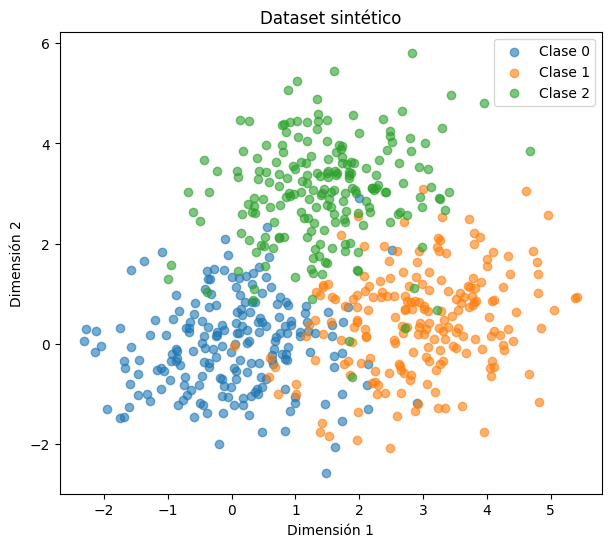

In [16]:
plt.figure(figsize=(7, 6))

for clase in np.unique(y):
    puntos = X_emb[y == clase]
    plt.scatter(puntos[:, 0],puntos[:, 1],alpha=0.6,label=f"Clase {clase}")

plt.xlabel("Dimensión 1")
plt.ylabel("Dimensión 2")
plt.title("Dataset sintético")
plt.legend()

plt.show()

In [17]:
result = compute_csg(X=X_emb,y=y,M=100,k=3,random_state=42)

print("CSG =", result["CSG"])

CSG = 0.6077204922507186


In [18]:
# Matriz S
result["S"]

,0,1,2
0,0.083633,0.013380,0.005773
1,0.010898,0.083806,0.007007
2,0.006247,0.010329,0.107711


In [19]:
# Matriz de adyacencia
result["W"]

,0,1,2
0,1.000000,0.293905,0.196836
1,0.293905,1.000000,0.208696
2,0.196836,0.208696,1.000000


In [20]:
# Laplaciano
result["L"]

,0,1,2
0,0.490741,-0.293905,-0.196836
1,-0.293905,0.502601,-0.208696
2,-0.196836,-0.208696,0.405532


In [21]:
# Autovalores
result["eigenvalues"]

array([0.        , 0.60772049, 0.79115333])

In [22]:
# Para entender las ecuaciones 6 y 7
result["spectral_details"]

,i,lambda_i,lambda_i+1,eigengap,K-i,normalized_eigengap,cummax
0,1,0.00000,0.607720,0.607720,2,0.303860,0.30386
1,2,0.60772,0.791153,0.183433,1,0.183433,0.30386


Comprobamos si se comporta como esperamos generando un dataset difícil y uno fácil.

In [23]:
def generar_dataset_sintetico(sigma=1.0, n=200, random_state=42):

    rng = np.random.default_rng(random_state)

    centros = [[0.0, 0.0],[3.0, 0.5],[1.5, 3.0]]

    X_list = []
    y_list = []

    for clase, centro in enumerate(centros):

        X_clase = rng.normal(loc=centro,scale=sigma,size=(n, 2))
        X_list.append(X_clase)
        y_list.append(np.full(n, clase))

    X = np.vstack(X_list)
    y = np.concatenate(y_list)

    return X, y

In [24]:
X_easy, y_easy = generar_dataset_sintetico(sigma=0.4)

In [25]:
X_hard, y_hard = generar_dataset_sintetico(sigma=1.5)

In [26]:
result_easy = compute_csg(X_easy,y_easy,M=100,k=3,random_state=42)
result_hard = compute_csg(X_hard,y_hard,M=100,k=3,random_state=42)

print("CSG dataset fácil:  ", result_easy["CSG"])
print("CSG dataset difícil:", result_hard["CSG"])

CSG dataset fácil:   0.012553951682036634
CSG dataset difícil: 1.691710252140654


In [27]:
print("=== DATASET FÁCIL ===")
print("\nS:")
display(result_easy["S"])

print("\nW:")
display(result_easy["W"])

print("\nAutovalores:")
print(result_easy["eigenvalues"])

print("\nCSG:")
display(result_easy["spectral_details"])


print("\n\n=== DATASET DIFÍCIL ===")
print("\nS:")
display(result_hard["S"])

print("\nW:")
display(result_hard["W"])

print("\nAutovalores:")
print(result_hard["eigenvalues"])

print("\nCSG:")
display(result_hard["spectral_details"])

=== DATASET FÁCIL ===

S:


,0,1,2
0,0.522705,0.000971,0.000698
1,0.000848,0.523785,0.001271
2,0.000670,0.000954,0.673194



W:


,0,1,2
0,1.000000,0.004795,0.003873
1,0.004795,1.000000,0.004822
2,0.003873,0.004822,1.000000



Autovalores:
[0.         0.01255395 0.01442456]

CSG:


...

,0,1,2
0,0.037170,0.024319,0.012471
1,0.012968,0.037247,0.016847
2,0.012001,0.014629,0.047872



W:


,0,1,2
0,1.000000,0.705673,0.526754
1,0.705673,1.000000,0.614244
2,0.526754,0.614244,1.000000



Autovalores:
[3.00269289e-16 1.69171025e+00 2.00163265e+00]

CSG:


,i,lambda_i,lambda_i+1,eigengap,K-i,normalized_eigengap,cummax
0,1,3.002693e-16,1.691710,1.691710,2,0.845855,0.845855
1,2,1.691710e+00,2.001633,0.309922,1,0.309922,0.845855
